# HOUSE PRICE PREDICITION

IMPORTING LIBRARIES



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer


In [2]:
df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")

In [3]:
df.corr

<bound method DataFrame.corr of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Ut

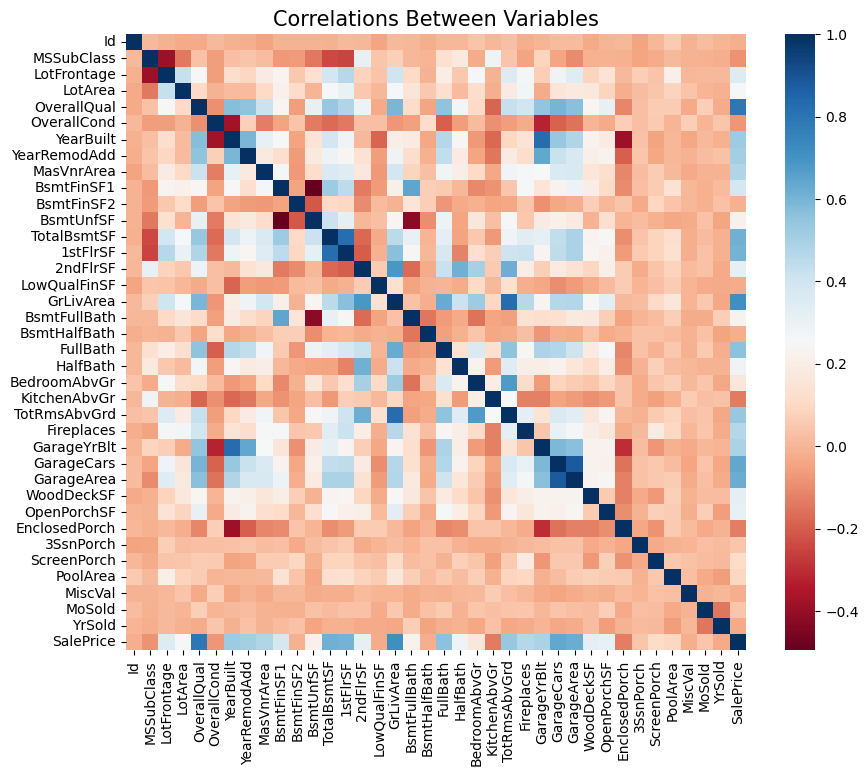

In [4]:
plt.figure(figsize=(10, 8))
# Add numeric_only=True inside the corr() function
sns.heatmap(df.corr(numeric_only=True), cmap="RdBu") 
plt.title("Correlations Between Variables", size=15)
plt.show()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
print("Missing Values by Column")
print("-"*30)
print(df.isna().sum())
print("-"*30)
print("TOTAL MISSING VALUES:",df.isna().sum().sum())

Missing Values by Column
------------------------------
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64
------------------------------
TOTAL MISSING VALUES: 7829


<Figure size 1000x800 with 0 Axes>

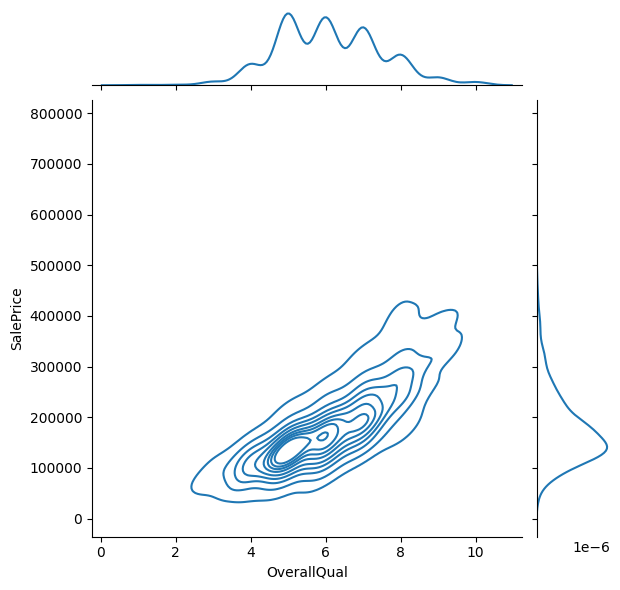

In [7]:
plt.figure(figsize=(10,8))
sns.jointplot(x=df["OverallQual"], y=df["SalePrice"], kind="kde")
plt.show()

In [8]:
sns.pairplot(df[important_num_cols])

NameError: name 'important_num_cols' is not defined

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=df["OverallQual"], y=df["SalePrice"])
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Scatter Plot")
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))
sns.jointplot(x=df["OverallQual"], y=df["SalePrice"], kind="hex")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Hexbin Plot")
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))
sns.regplot(x=df["OverallQual"], y=df["SalePrice"])
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Regression Plot")
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(x=df["OverallQual"], y=df["SalePrice"])
plt.xlabel("Overall Quality")
plt.ylabel("Mean Sale Price")
plt.title("Bar Plot with Mean")
plt.show()

In [ ]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [ ]:
# Create a list of all columns that have 'object' (text) data types
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Now run your dummy encoding
X = pd.get_dummies(X, columns=cat_cols)

In [ ]:
important_num_cols.remove("SalePrice")

scaler = StandardScaler()
X[important_num_cols] = scaler.fit_transform(X[important_num_cols])

In [ ]:
X.head()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=121)

In [ ]:
def rmse_cv(model):
    rmse = np.sqrt(-cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=5)).mean()
    return rmse
    

def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mean_squared_error(y, predictions))
    r_squared = r2_score(y, predictions)
    return mae, mse, rmse, r_squared

In [ ]:
models = pd.DataFrame(columns=["Model","MAE","MSE","RMSE","R2 Score","RMSE (Cross-Validation)"])

In [ ]:
from sklearn.impute import SimpleImputer

# 1. Create an imputer (using 'mean' or 'median' for numerical data)
imputer = SimpleImputer(strategy='median')

# 2. Fill the missing values in your features
# Note: This will return a numpy array, so we wrap it back into a DataFrame
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 3. Now perform your split using the imputed data
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=121)

# 4. Now your model will work!
l_reg = LinearRegression()
l_reg.fit(X_train, y_train)
predictions = l_reg.predict(X_test)

In [ ]:
predictions

In [ ]:
# Updated Cell [23]
models = pd.DataFrame({
    "Model": pd.Series(dtype='str'),
    "MAE": pd.Series(dtype='float'),
    "MSE": pd.Series(dtype='float'),
    "RMSE": pd.Series(dtype='float'),
    "R2 Score": pd.Series(dtype='float'),
    "RMSE (Cross-Validation)": pd.Series(dtype='float')
})

In [ ]:
ridge_reg = Ridge(alpha=0.5)  # You can adjust the alpha parameter
ridge_reg.fit(X_train, y_train)
predictions_ridge = ridge_reg.predict(X_test)

In [ ]:
predictions_ridge

In [ ]:
# Create a DataFrame for the new row
new_row_df = pd.DataFrame([{"Model": "Ridge Regression", 
                            "MAE": mae, 
                            "MSE": mse, 
                            "RMSE": rmse, 
                            "R2 Score": r_squared, 
                            "RMSE (Cross-Validation)": rmse_cross_val}])

# Use pd.concat to add the row to your existing models table
models = pd.concat([models, new_row_df], ignore_index=True)

# Display the updated table
models

In [ ]:
# 1. Define and Fit Lasso with increased iterations
lasso_reg = Lasso(alpha=0.5, max_iter=10000)
lasso_reg.fit(X_train, y_train)
predictions_lasso = lasso_reg.predict(X_test)

# 2. Get Evaluation Metrics
mae, mse, rmse, r_squared = evaluation(y_test, predictions_lasso)

# 3. Get Cross-Validation Score (using X_imputed)
rmse_cross_val = rmse_cv(lasso_reg)

# 4. Create the row and add it to the table
new_row_lasso = pd.DataFrame([{
    "Model": "Lasso Regression", 
    "MAE": mae, "MSE": mse, "RMSE": rmse, 
    "R2 Score": r_squared, 
    "RMSE (Cross-Validation)": rmse_cross_val
}])

models = pd.concat([models, new_row_lasso], ignore_index=True)
models

In [ ]:
predictions_lasso

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR

# Example dataset
X = [[1], [2], [3], [4], [5]]
y = [2, 4, 6, 8, 10]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create SVR model
svr_reg = SVR(kernel='rbf')

# Train model
svr_reg.fit(X_train, y_train)

# Predict
predictions_svr = svr_reg.predict(X_test)

print(predictions_svr)

In [ ]:
predictions_svr

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

# Sample dataset
data = pd.DataFrame({
    'math': [80, 90, 70, 60, 85],
    'science': [75, 85, 65, 70, 80],
    'marks': [78, 88, 68, 65, 82]
})

# Features and target
X = data.drop('marks', axis=1)
y = data['marks']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
gb_reg = GradientBoostingRegressor(n_estimators=100)

# Train model
gb_reg.fit(X_train, y_train)

# Predict
predictions_gb = gb_reg.predict(X_test)

print(predictions_gb)

In [ ]:
predictions_gb

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluation(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r_squared = r2_score(y_true, y_pred)

    return mae, mse, rmse, r_squared

In [ ]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions_gb)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)

In [ ]:
xgb_reg = XGBRegressor(n_estimators=100)  # You can adjust the number of estimators
xgb_reg.fit(X_train, y_train)
predictions_xgb = xgb_reg.predict(X_test)

In [ ]:
predictions_xgb

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Example dataset
# Replace this with your actual dataset
data = pd.DataFrame({
    'feature1': [10, 20, 30, 40, 50, 60, 70, 80],
    'feature2': [5, 10, 15, 20, 25, 30, 35, 40],
    'target': [15, 25, 35, 45, 55, 65, 75, 85]
})

# Features and target
X = data.drop('target', axis=1)
y = data['target']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Create model
xgb_reg = XGBRegressor()

# Train model
xgb_reg.fit(X_train, y_train)

# Predictions
predictions_xgb = xgb_reg.predict(X_test)

# Evaluation function
def evaluation(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r_squared = r2_score(y_true, y_pred)

    return mae, mse, rmse, r_squared

# Cross-validation function
def rmse_cv(model):
    rmse = np.sqrt(
        -cross_val_score(
            model,
            X,
            y,
            scoring="neg_mean_squared_error",
            cv=5
        )
    )

    return rmse.mean()

# Evaluate model
mae, mse, rmse, r_squared = evaluation(y_test, predictions_xgb)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)

print("-" * 30)

# Cross-validation
rmse_cross_val = rmse_cv(xgb_reg)

print("RMSE Cross-Validation:", rmse_cross_val)

# Store results
models = pd.DataFrame(columns=[
    "Model",
    "MAE",
    "MSE",
    "RMSE",
    "R2 Score",
    "RMSE (Cross-Validation)"
])

new_row = {
    "Model": "XGBRegressor",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r_squared,
    "RMSE (Cross-Validation)": rmse_cross_val
}

models.loc[len(models)] = new_row

print("-" * 30)
print(models)

In [ ]:
models.sort_values(by="RMSE (Cross-Validation)")

In [ ]:
plt.figure(figsize=(12,8))
sns.barplot(x=models["Model"], y=models["RMSE (Cross-Validation)"])
plt.title("Models' RMSE Scores (Cross-Validated)", size=15)
plt.xticks(rotation=30, size=12)
plt.show()

In [ ]:
df.isna()

In [ ]:
df.isna().sum()

In [ ]:
lgb_reg = lgb.LGBMRegressor(n_estimators=100)  # You can adjust the number of estimators
lgb_reg.fit(X_train, y_train)
predictions_lgb = lgb_reg.predict(X_test)

In [ ]:
predictions_lgb

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(x=df["OverallQual"], y=df["SalePrice"])
plt.xlabel("Overall Quality")
plt.ylabel("Mean Sale Price")
plt.title("Bar Plot with Mean")
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Ensure X is correctly defined from the original dataframe
# (Drop the target 'SalePrice' to create your feature set)
X = df.drop("SalePrice", axis=1)

# 2. Define your list of columns to scale
important_num_cols = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF']

# 3. Apply the scaler
scaler = StandardScaler()
X[important_num_cols] = scaler.fit_transform(X[important_num_cols])

# Verify it worked
print("Scaled columns successfully!")
X[important_num_cols].head()